<h1 align="center"> Introduction to Statistics with Python </h1>



## 


#### MSc Mathematical and Computational Finance
#### Mathematical Institute
#### University of Oxford


**Course Term:** Michaelmas (2022-2023)

**Lecturer:** Katia Babbar

**email:** katia.babbar@maths.ox.ac.uk

**Course Overview:**  6hrs MT

Financial Data Sets
====

There are a series of free available resources of financial data in the web. These can be usually downloaded in csv files and subsequently imported as "pandas dataframes". Dataframes are special data structures in Python which will be introduced more formally during the Python course. For the time being, view them as useful indexed tables which facilitate data analysis and have some useful inbuilt methods which we will explore next.  

Some Python packages assist in the downloading of financial data and subsequent assingment of this data to a dataframe. One such package is "pandas_datareader". 



In [2]:
import pandas_datareader as pd_data
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy as sp
import scipy.stats as stats
import math as m
from datetime import datetime
from dateutil.parser import parse
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [4]:
start_date = '2010-01-01'
end_date = '2019-08-14'
EURUSDFull = pd_data.DataReader('EURUSD=X','yahoo',start_date,end_date)

In [9]:
EURUSDFull.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2010-01-01,1.440196,1.432706,1.432706,1.438994,0.0,1.438994
2010-01-04,1.445191,1.426208,1.431004,1.442398,0.0,1.442398
2010-01-05,1.448310,1.435194,1.442710,1.436596,0.0,1.436596
2010-01-06,1.443460,1.429123,1.436596,1.440403,0.0,1.440403
2010-01-07,1.444481,1.430206,1.440300,1.431803,0.0,1.431803


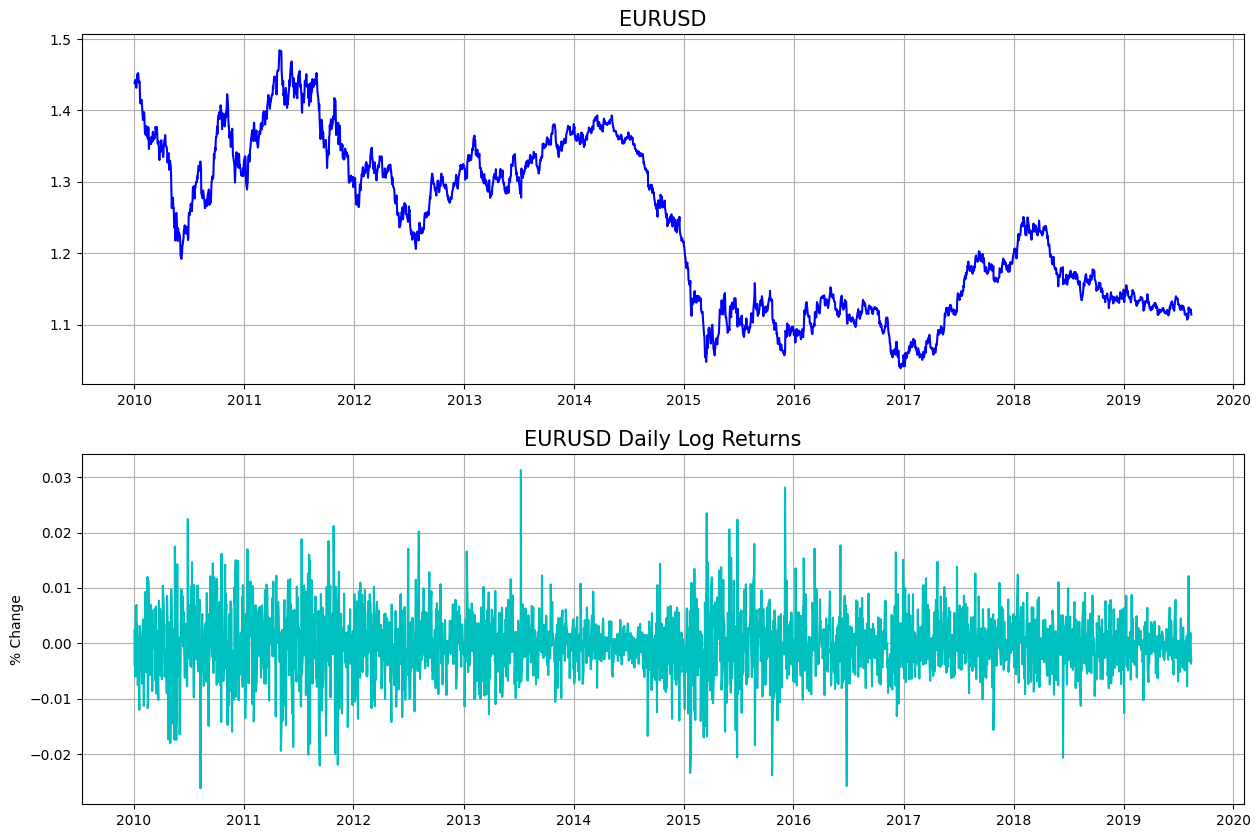

In [10]:
#mask = (((EURUSDFull.index >= '2018-6-27') & (EURUSDFull.index <= '2016-6-27 5:00'))) 

EURUSD =EURUSDFull['2010':'2019']
EURUSDLogRtn = np.log(EURUSD['Close']).diff().dropna()

plt.figure(1, figsize=(15,10)) # overall dimnesions 
plt.subplot(2,1, 1) # 2 by 1 and plot 1
plt.title('EURUSD',size = 15)
plt.plot(EURUSD['Close'], 'b')
plt.grid()
plt.subplot(2,1, 2) # 2 by 1 and plot 2
plt.plot(EURUSDLogRtn, 'c')
plt.title('EURUSD Daily Log Returns',size = 15)
plt.ylabel('% Change')
plt.grid()

-0.00010211283472831417 0.005784115633888089


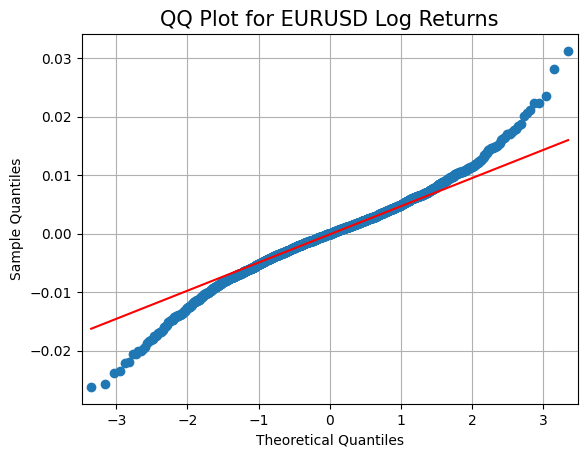

In [11]:
import statsmodels.api as sm
mean = EURUSDLogRtn.mean()
stdDev= EURUSDLogRtn.std()
print(mean,stdDev)
fig = sm.qqplot(EURUSDLogRtn, line = 'q')
plt.title('QQ Plot for EURUSD Log Returns', fontsize=15)
plt.grid()
plt.show()

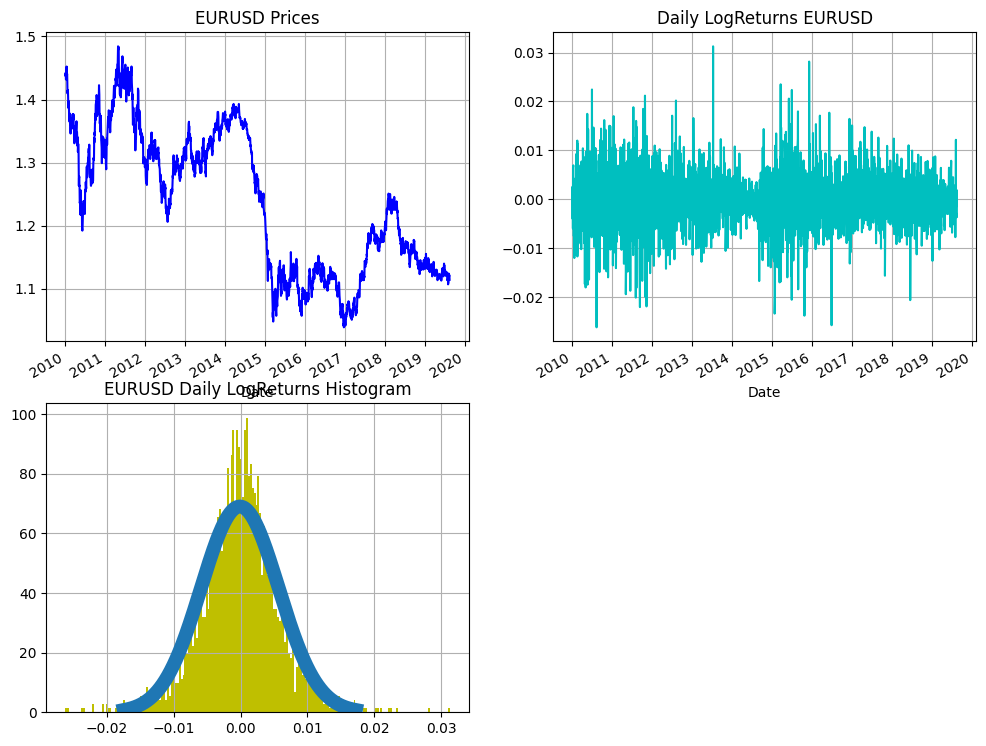

In [13]:
plt.figure(1, figsize=(15,10)) # overall dimnesions 
plt.subplot(2,2, 1) # 2 by 1 and plot 1
plt.title('EURUSD Prices')
EURUSD['Close'].plot(c ='b')
plt.grid()
plt.subplot(2,2, 2) # 2 by 1 and plot 2
EURUSDLogRtn.plot(c= 'c')
plt.title('Daily LogReturns EURUSD')
plt.grid()
plt.subplot(2,2, 3) # 2 by 1 and plot 1
EURUSDLogRtn = EURUSDLogRtn
EURUSDLogRtn.hist(bins = 200, figsize = (12 ,10), color='y', density = True)
plt.title('EURUSD Daily LogReturns Histogram')
mu = EURUSDLogRtn.mean()
sigma = EURUSDLogRtn.std()
kurt = EURUSDLogRtn.kurt()
skew = EURUSDLogRtn.skew()
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 2419)
myplot = plt.plot(x, stats.norm.pdf(x, mu, sigma), linewidth= 10)
plt.show()

In [14]:
#Grab full market data for daily observations of chosen fx, equity and indices
EURUSDFull = pd_data.DataReader('EURUSD=X','yahoo',start_date,end_date)
GBPUSDFull = pd_data.DataReader('GBPUSD=X','yahoo',start_date,end_date)
EURCHFFull = pd_data.DataReader('EURCHF=X','yahoo',start_date,end_date)
USDJPYFull = pd_data.DataReader('USDJPY=X','yahoo',start_date,end_date)

In [15]:

#Select period of interest
EURUSD = EURUSDFull['2009':'2018']
GBPUSD = GBPUSDFull['2014':'2017']

In [16]:
GBPUSD

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2014-01-01,1.656397,1.656397,1.656397,1.656397,0.0,1.656397
2014-01-02,1.660495,1.642387,1.657660,1.658072,0.0,1.658072
2014-01-03,1.647501,1.640070,1.645007,1.644791,0.0,1.644791
2014-01-06,1.643304,1.634254,1.641201,1.641309,0.0,1.641309
2014-01-07,1.643548,1.637546,1.641497,1.641794,0.0,1.641794
...,...,...,...,...,...,...
2017-12-25,1.339585,1.336309,1.336720,1.336505,0.0,1.336505
2017-12-26,1.337972,1.334917,1.337489,1.337614,0.0,1.337614
2017-12-27,1.343183,1.337041,1.337381,1.337471,0.0,1.337471


Text(0.5, 1.0, 'EURCHF Daily LogReturns Histogram')

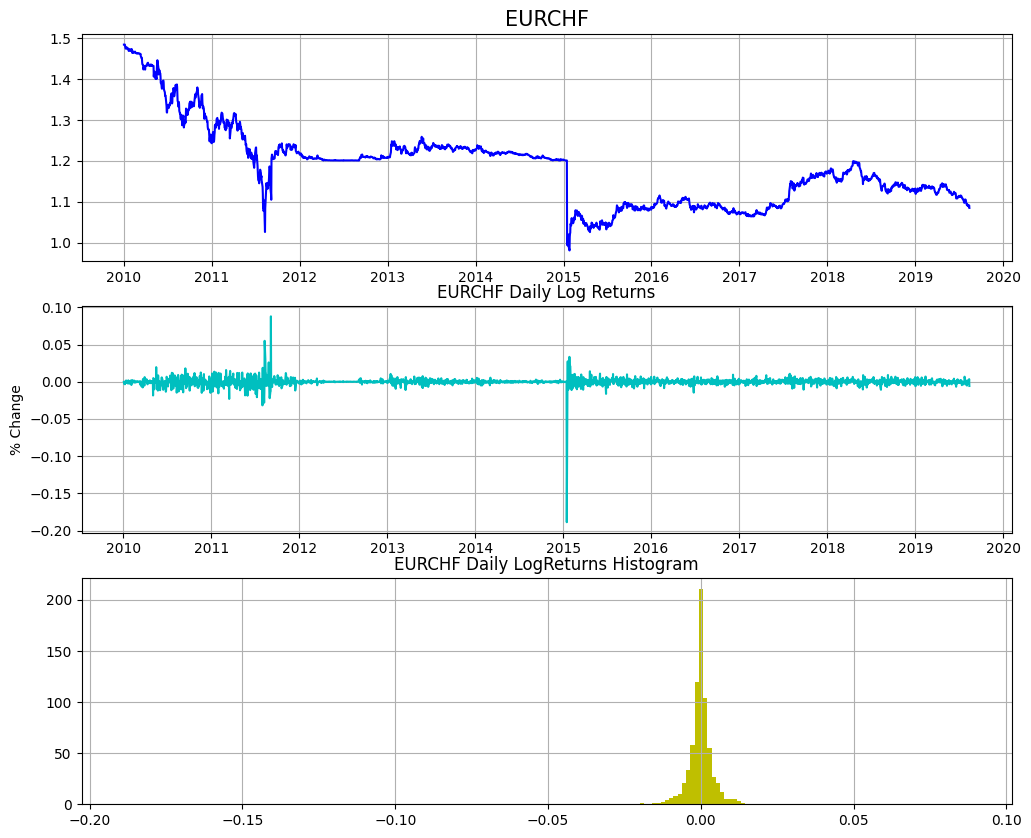

In [17]:
#mask = (((EURUSDFull.index >= '2018-6-27') & (EURUSDFull.index <= '2016-6-27 5:00'))) 

EURCHF =EURCHFFull['2001':'2019']
EURCHFLogRtn = np.log(EURCHF['Close']).diff().dropna()

plt.figure(1, figsize=(12,10)) # overall dimnesions 
plt.subplot(3,1, 1) # 2 by 1 and plot 1
plt.title('EURCHF',size = 15)
plt.plot(EURCHF['Close'], 'b')
plt.grid()
plt.subplot(3,1, 2) # 2 by 1 and plot 2
plt.plot(EURCHFLogRtn, 'c')
plt.title('EURCHF Daily Log Returns',size = 12)
plt.ylabel('% Change')
plt.grid()
plt.subplot(3,1, 3) # 2 by 1 and plot 2
EURCHFLogRtn.hist(bins = 200, figsize = (12 ,10), color='y', density = True)
plt.title('EURCHF Daily LogReturns Histogram')

Text(0.5, 1.0, 'EURCHF Daily LogReturns Histogram')

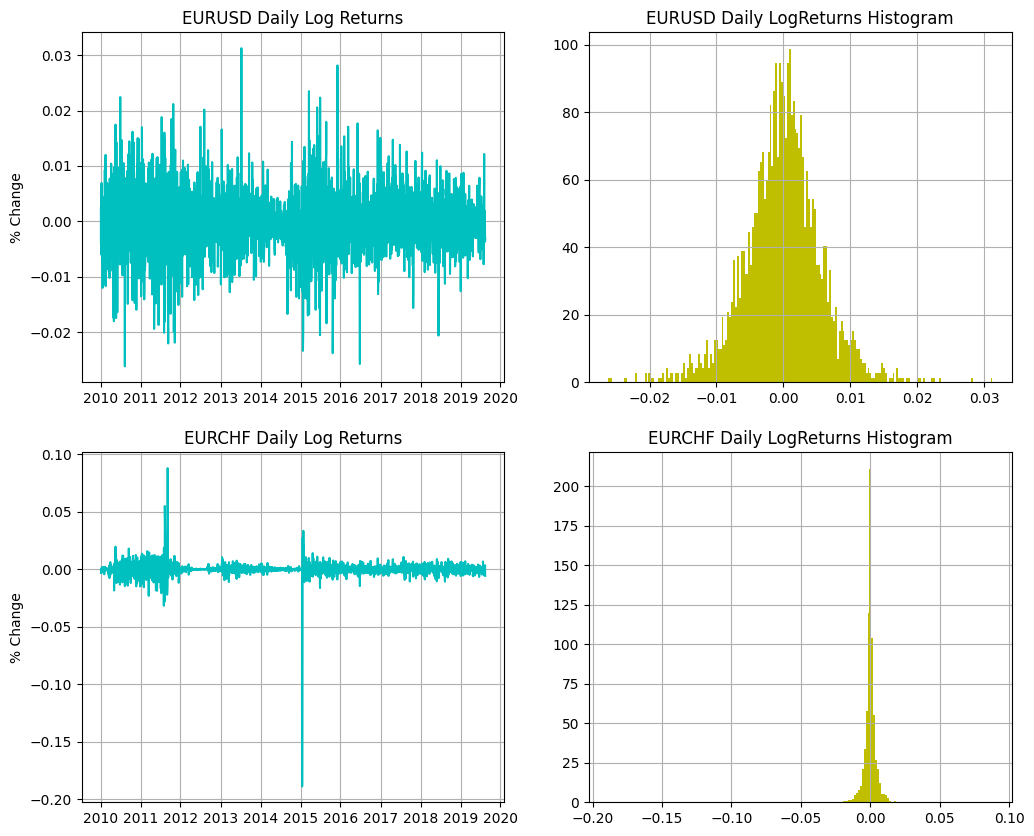

In [18]:
plt.figure(1, figsize=(12,10)) # overall dimnesions 
plt.subplot(2,2, 1)
plt.plot(EURUSDLogRtn, 'c')
plt.title('EURUSD Daily Log Returns',size = 12)
plt.ylabel('% Change')
plt.grid()
plt.subplot(2,2, 2) 
EURUSDLogRtn.hist(bins = 200, figsize = (12 ,10), color='y', density = True)
plt.title('EURUSD Daily LogReturns Histogram')
plt.subplot(2,2, 3) 
plt.plot(EURCHFLogRtn, 'c')
plt.title('EURCHF Daily Log Returns',size = 12)
plt.ylabel('% Change')
plt.grid()
plt.subplot(2,2, 4) # 2 by 1 and plot 2
EURCHFLogRtn.hist(bins = 200, figsize = (12 ,10), color='y', density = True)
plt.title('EURCHF Daily LogReturns Histogram')


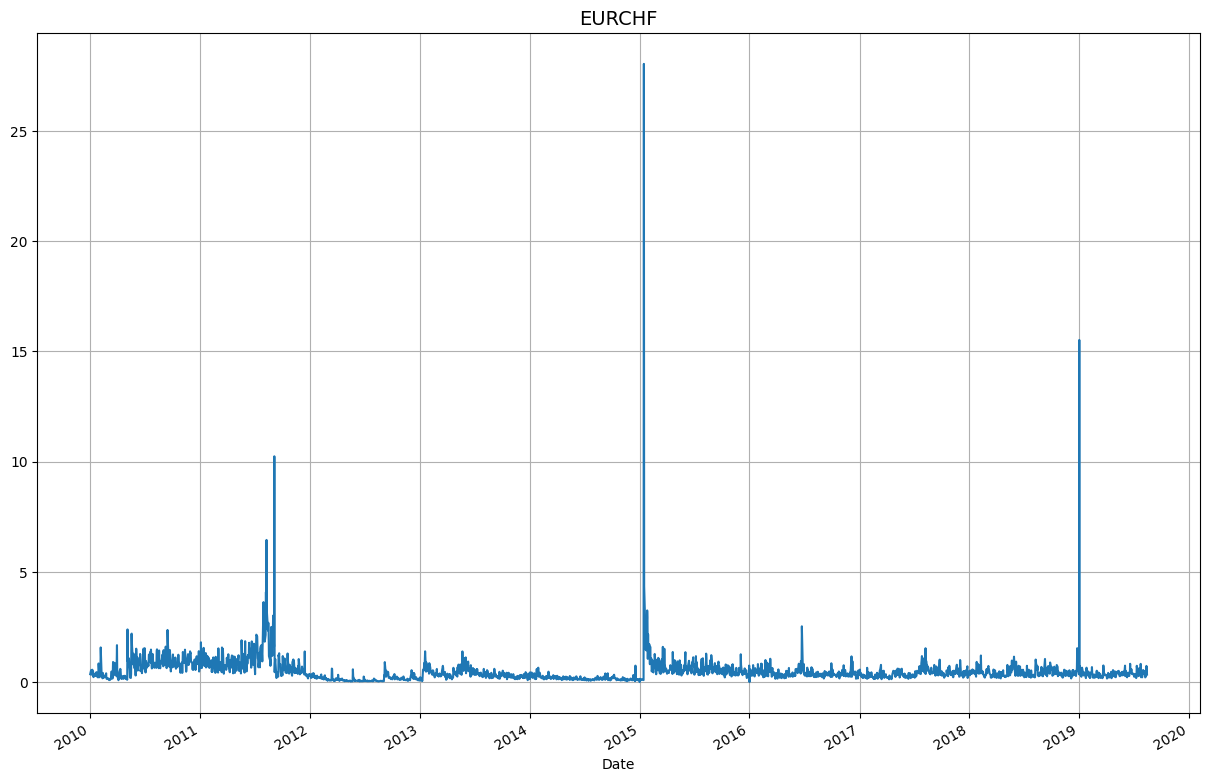

In [19]:
x = (EURCHF['High']-EURCHF['Low'])/EURCHF['Open']*100
x.plot(figsize = (15, 10), grid = True)
plt.title('EURCHF', fontsize=14)
plt.show()

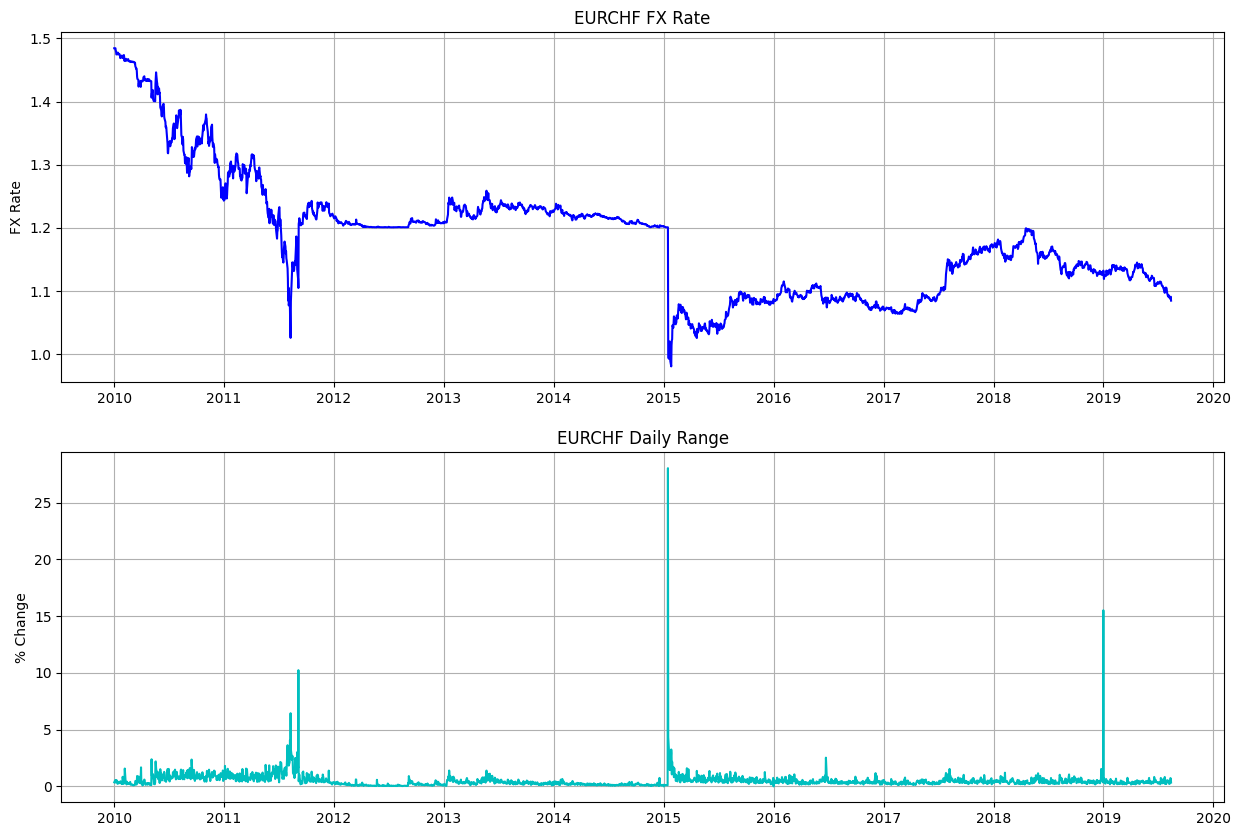

In [20]:
plt.figure(1, figsize=(15,10)) # overall dimnesions 
plt.subplot(2,1, 1) # 2 by 1 and plot 1
plt.title('EURCHF FX Rate')
plt.plot(EURCHF['Close'], 'b')
plt.ylabel('FX Rate')
plt.grid()
plt.subplot(2,1, 2) # 2 by 1 and plot 2
plt.plot(x, 'c')
plt.title('EURCHF Daily Range')
plt.ylabel('% Change')
plt.grid()

In [21]:
EURCHF['2011'].idxmin()

High        2011-08-09
Low         2011-08-10
Open        2011-08-10
Close       2011-08-10
Volume      2011-01-03
Adj Close   2011-08-10
dtype: datetime64[ns]

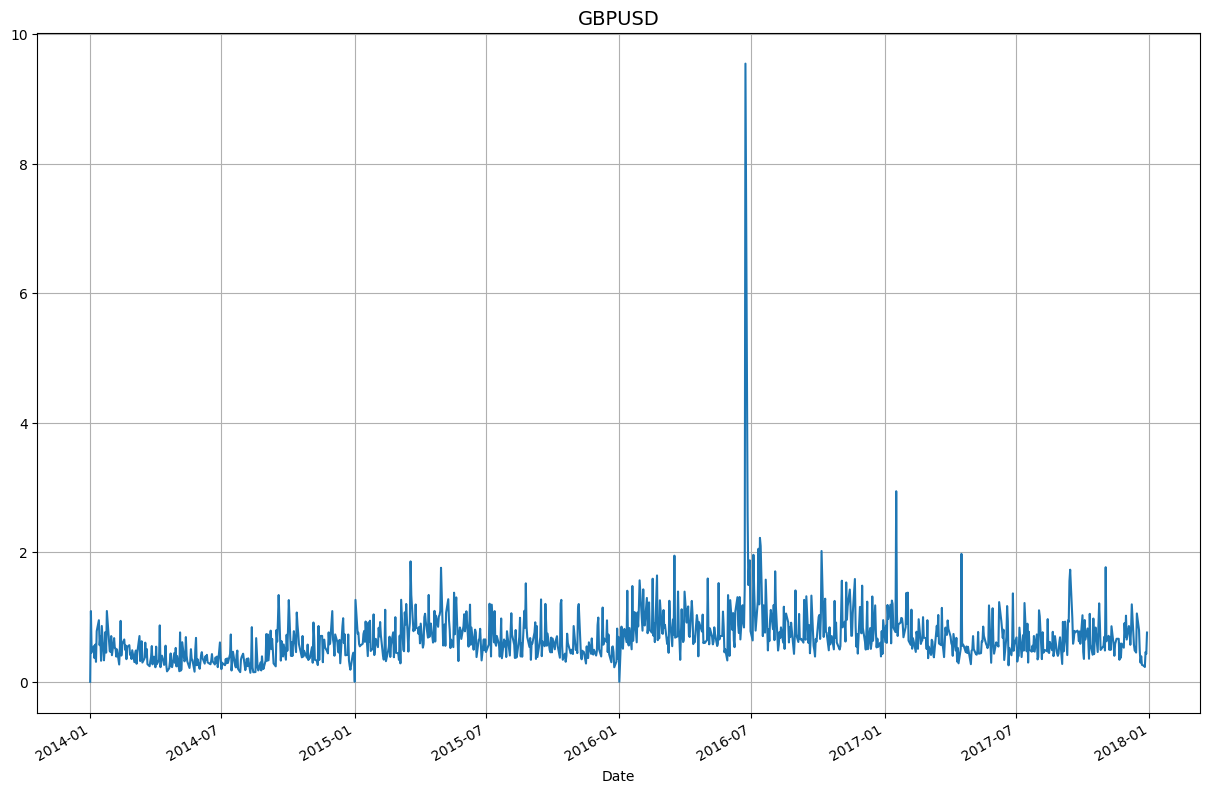

In [22]:
y = (GBPUSD['High']-GBPUSD['Low'])/GBPUSD['Open']*100
y.plot(figsize = (15, 10), grid = True)
plt.title('GBPUSD', fontsize=14)
plt.show()

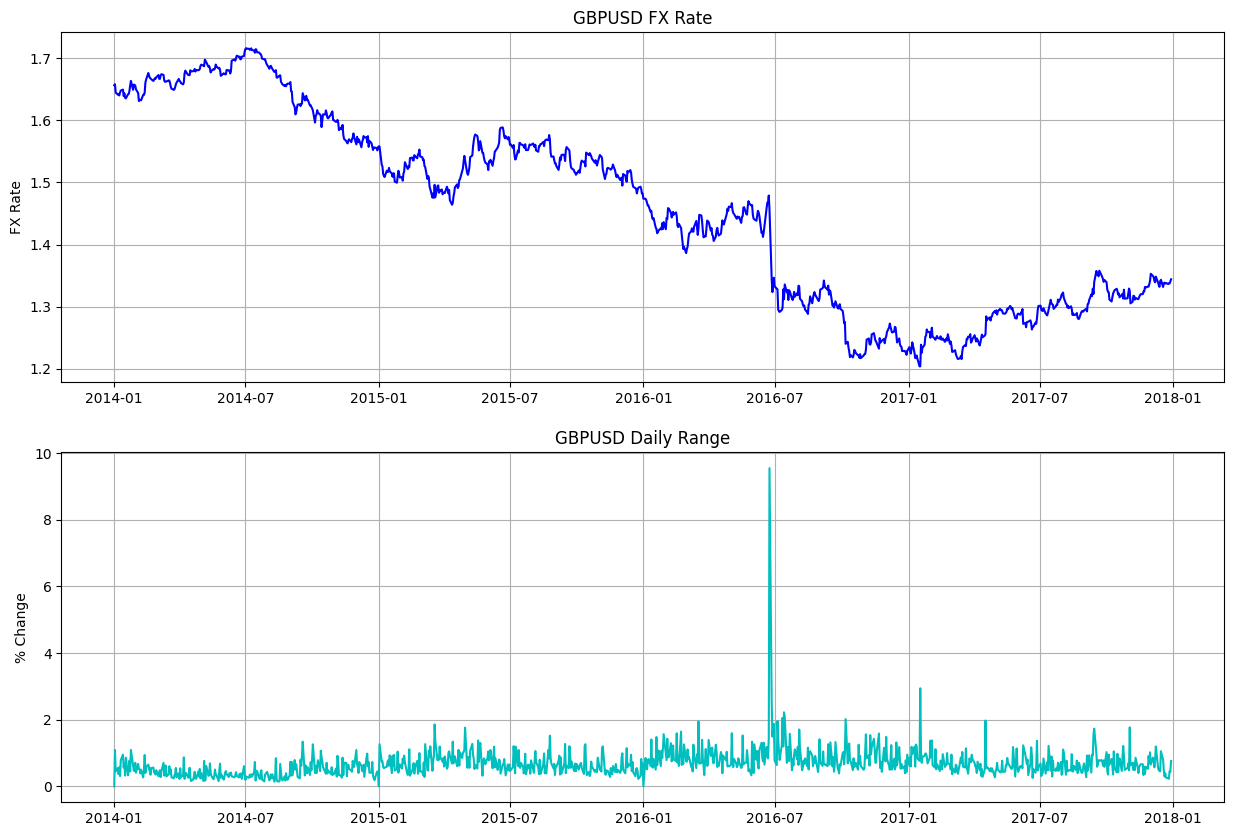

In [23]:
plt.figure(1, figsize=(15,10)) # overall dimnesions 
plt.subplot(2,1, 1) # 2 by 1 and plot 1
plt.title('GBPUSD FX Rate')
plt.plot(GBPUSD['Close'], 'b')
plt.ylabel('FX Rate')
plt.grid()
plt.subplot(2,1, 2) # 2 by 1 and plot 2
plt.plot(y, 'c')
plt.title('GBPUSD Daily Range')
plt.ylabel('% Change')
plt.grid()

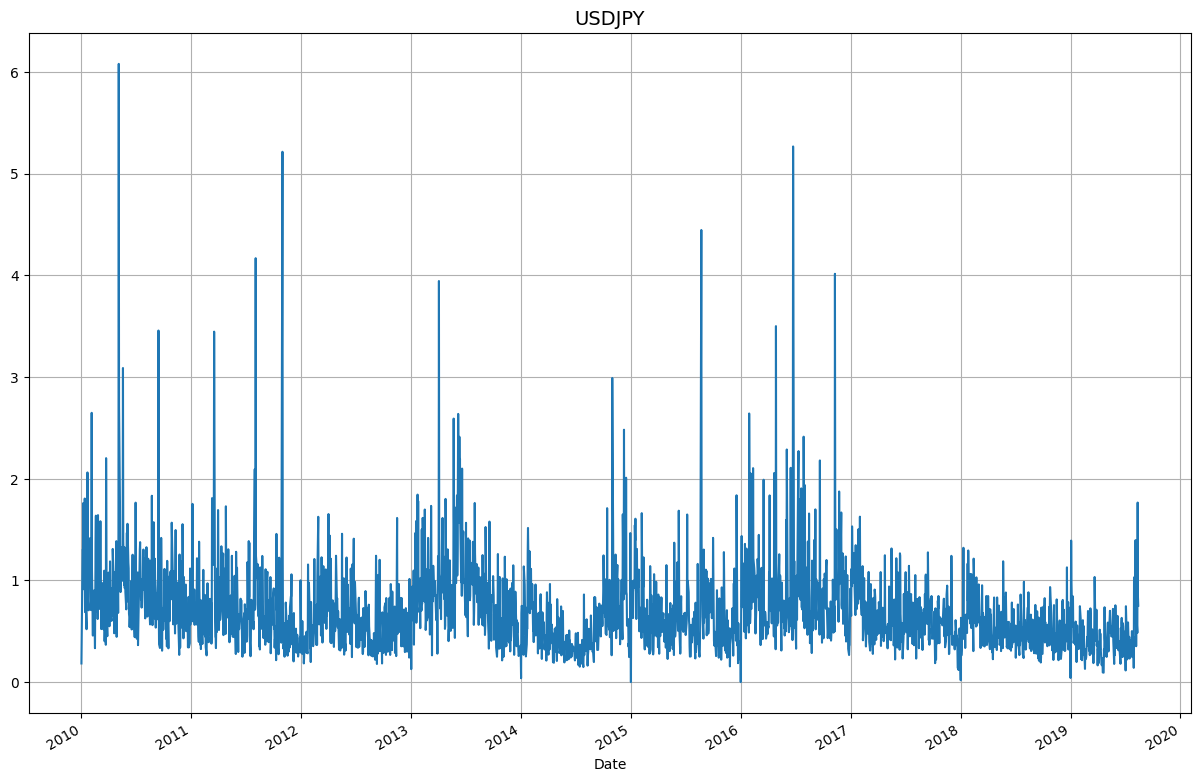

In [24]:
z = (USDJPYFull['High']-USDJPYFull['Low'])/USDJPYFull['Open']*100
z.plot(figsize = (15, 10), grid = True)
plt.title('USDJPY', fontsize=14)
plt.show()

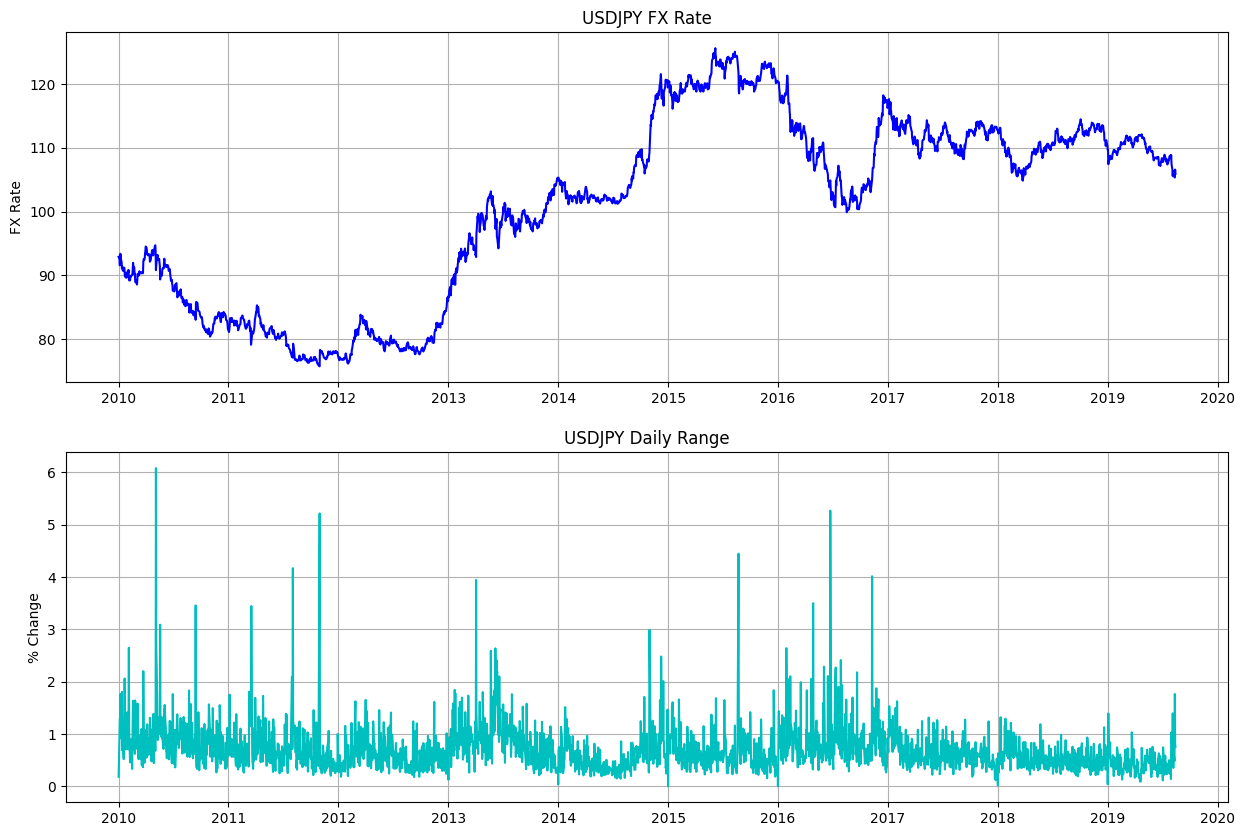

In [25]:
plt.figure(1, figsize=(15,10)) # overall dimnesions 
plt.subplot(2,1, 1) # 2 by 1 and plot 1
plt.title('USDJPY FX Rate')
plt.plot(USDJPYFull['Close'], 'b')
plt.ylabel('FX Rate')
plt.grid()
plt.subplot(2,1, 2) # 2 by 1 and plot 2
plt.plot(z, 'c')
plt.title('USDJPY Daily Range')
plt.ylabel('% Change')
plt.grid()

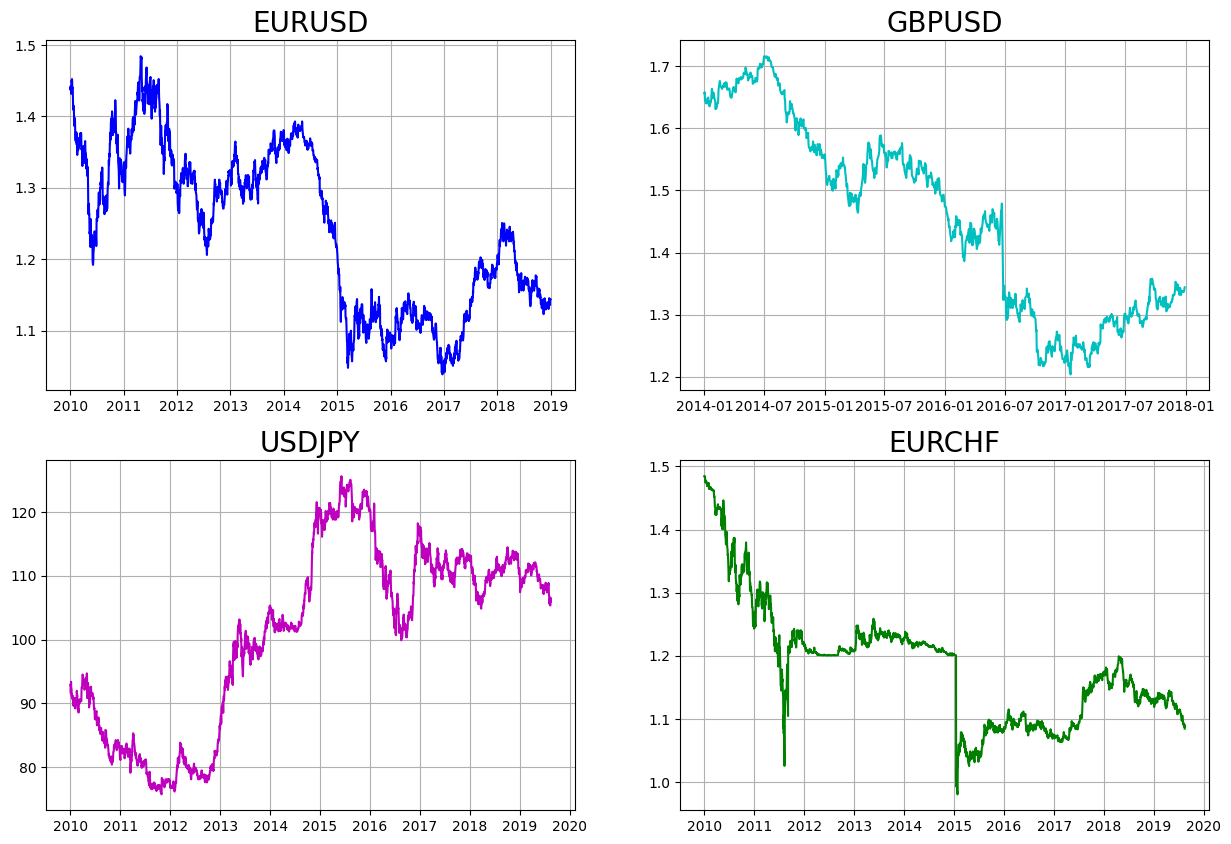

In [26]:
plt.figure(1, figsize=(15,10)) # overall dimnesions 
plt.subplot(2,2, 1) # 2 by 1 and plot 1
plt.title('EURUSD',size = 20)
plt.plot(EURUSD['Close'], 'b')
plt.grid()
plt.subplot(2,2, 2) # 2 by 1 and plot 2
plt.title('GBPUSD', size = 20)
plt.plot(GBPUSD['Close'], 'c')
plt.grid()
plt.subplot(2,2, 3) # 2 by 1 and plot 2
plt.title('USDJPY',size = 20)
plt.plot(USDJPYFull['Close'], 'm')
plt.grid()
plt.subplot(2,2,4) # 2 by 1 and plot 2
plt.title('EURCHF',size = 20)
plt.plot(EURCHF['Close'], 'g')
plt.grid()
plt.show()


In [33]:
#Grab full market data for daily adjusted closed observations of chosen fx, equity and indices
GoogleFull= pd_data.DataReader('GOOG','yahoo',start_date,end_date)
AmazonFull= pd_data.DataReader('AMZ','yahoo',start_date,end_date)
AppleFull= pd_data.DataReader('AAPL','yahoo',start_date,end_date)
IntelFull= pd_data.DataReader('INTC','yahoo',start_date,end_date)

In [34]:
#Select period of interest
Google = GoogleFull['2006':'2018']
Amazon = AmazonFull['2014':'2018']
Apple = AppleFull['2014':'2018']
Intel = IntelFull['2014':'2018']

In [35]:
Google.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2010-01-04,15.678981,15.547723,15.615220,15.610239,78541293.0,15.610239
2010-01-05,15.637387,15.480475,15.620949,15.541497,120638494.0,15.541497
2010-01-06,15.588072,15.102393,15.588072,15.149715,159744526.0,15.149715
2010-01-07,15.193053,14.760922,15.178109,14.797037,257533695.0,14.797037
2010-01-08,15.024933,14.672753,14.744733,14.994298,189680313.0,14.994298


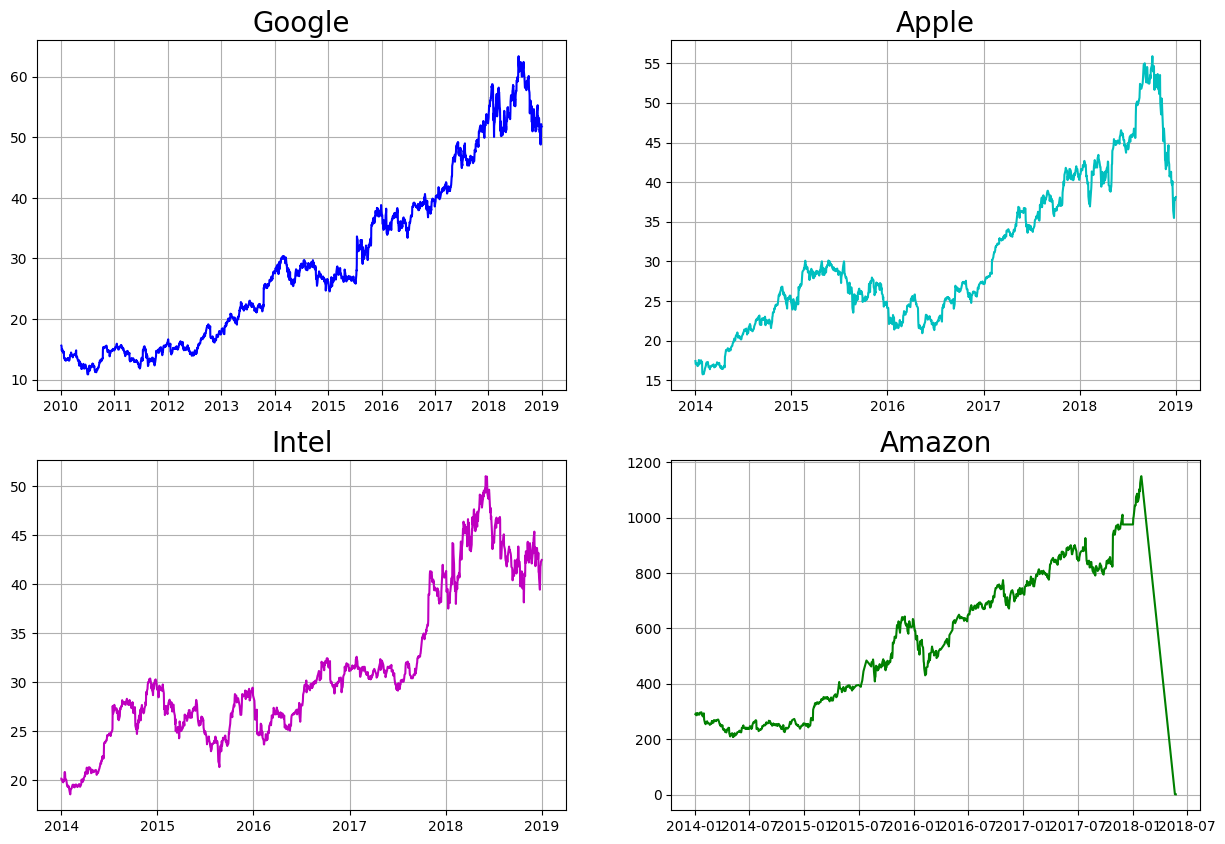

In [37]:
plt.figure(1, figsize=(15,10)) # overall dimnesions 
plt.subplot(2,2, 1) # 2 by 1 and plot 1
plt.title('Google',size = 20)
plt.plot(Google['Close'], 'b')
plt.grid()
plt.subplot(2,2, 2) # 2 by 1 and plot 2
plt.title('Apple',size = 20)
plt.plot(Apple['Adj Close'], 'c')
plt.grid()
plt.subplot(2,2, 3) # 2 by 1 and plot 2
plt.title('Intel',size = 20)
plt.plot(Intel['Adj Close'], 'm')
plt.grid()
plt.subplot(2,2,4) # 2 by 1 and plot 2
plt.title('Amazon',size = 20)
plt.plot(Amazon['Adj Close'], 'g')
plt.grid()
plt.show()


In [38]:
#Grab full market data for daily adjusted closed observations of chosen fx, equity and indices
QQQFull= pd_data.DataReader('QQQ','yahoo',start_date,end_date)

In [39]:
#Grab full market data for daily adjusted closed observations of chosen fx, equity and indices
SPYFull= pd_data.DataReader('SPY','yahoo',start_date,end_date) 
DIAFull= pd_data.DataReader('DIA','yahoo',start_date,end_date)

In [41]:
#Select period of interest
SPY = SPYFull['2014':'2018'] #ETF tracks S&P 500
DIA = DIAFull['2014':'2018'] #ETF tracks Dow Jones Industrial Avarage
QQQ = QQQFull['2014':'2018'] # ETF Tracks Nasdaq 100

In [42]:
QQQ.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2014-01-02,87.580002,87.019997,87.550003,87.269997,29177500.0,80.763123
2014-01-03,87.349998,86.620003,87.269997,86.639999,35723700.0,80.180107
2014-01-06,86.760002,86.000000,86.660004,86.320000,32073100.0,79.883980
2014-01-07,87.250000,86.559998,86.720001,87.120003,25860600.0,80.624336
2014-01-08,87.550003,86.949997,87.139999,87.309998,27197400.0,80.800148


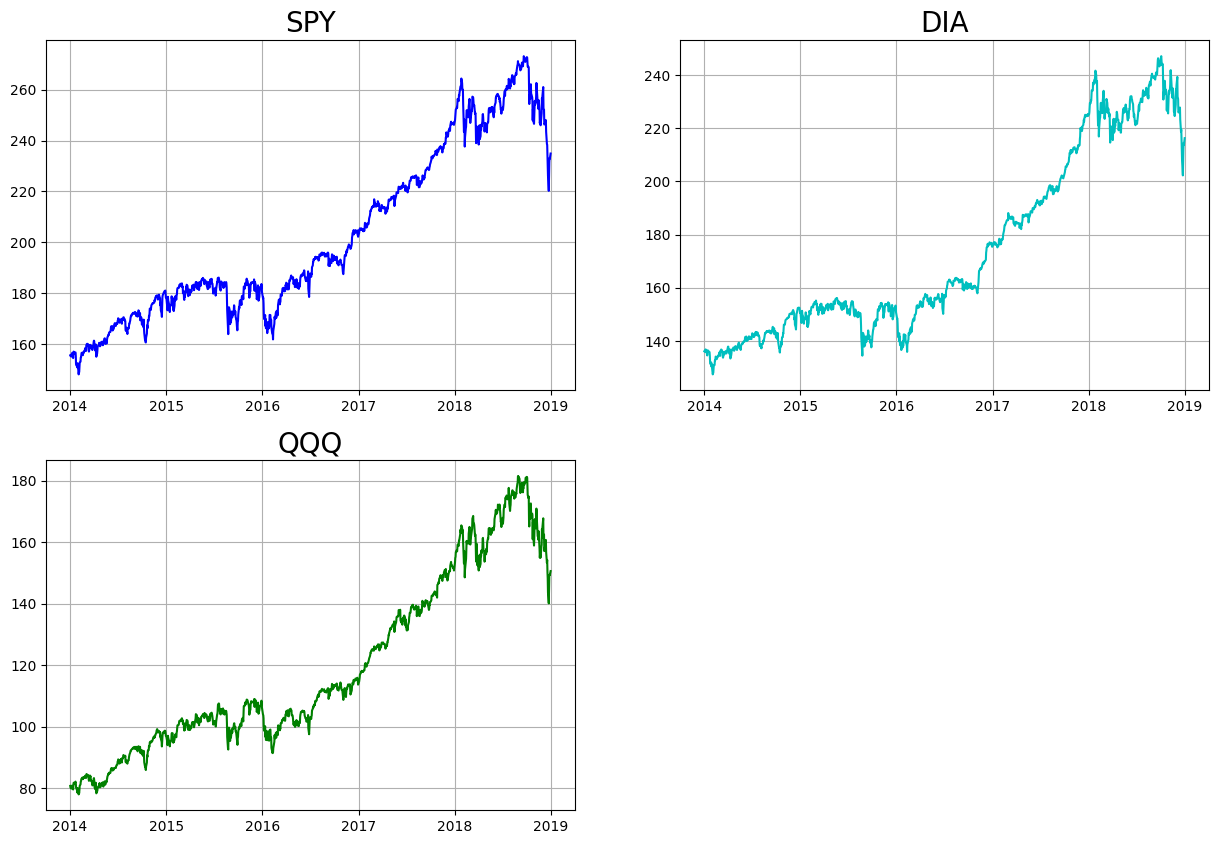

In [43]:
plt.figure(1, figsize=(15,10)) # overall dimnesions 
plt.subplot(2,2, 1) # 2 by 1 and plot 1
plt.title('SPY',size = 20)
plt.plot(SPY['Adj Close'], 'b')
plt.grid()
plt.subplot(2,2, 2) # 2 by 1 and plot 2
plt.title('DIA',size = 20)
plt.plot(DIA['Adj Close'], 'c')
plt.grid()
#plt.subplot(2,2, 3) # 2 by 1 and plot 2
#plt.title('FTSE',size = 20)
#plt.plot(FTSE['5. adjusted close'], 'm')
#plt.grid()
plt.subplot(2,2,3) # 2 by 1 and plot 2
plt.title('QQQ',size = 20)
plt.plot(QQQ['Adj Close'], 'g')
plt.grid()
plt.show()

In [45]:
GBPUSD = GBPUSDFull['2016-08-19': '2019-08-16']
EURUSD = EURUSDFull['2016-08-19': '2019-08-16']
GBPUSDLogRtn = np.log(GBPUSD['Close']).diff().dropna() #diff = log(p(t)-log(p(t-1))= log(p(t)/p(t-1)),continuosly compounded return
EURUSDLogRtn = np.log(EURUSD['Close']).diff().dropna() #diff = log(p(t)-log(p(t-1))= log(p(t)/p(t-1)),continuosly compounded return
EURCHFLogRtn = np.log(EURCHF['Close']).diff().dropna() #diff = log(p(t)-log(p(t-1))= log(p(t)/p(t-1)),continuosly compounded return



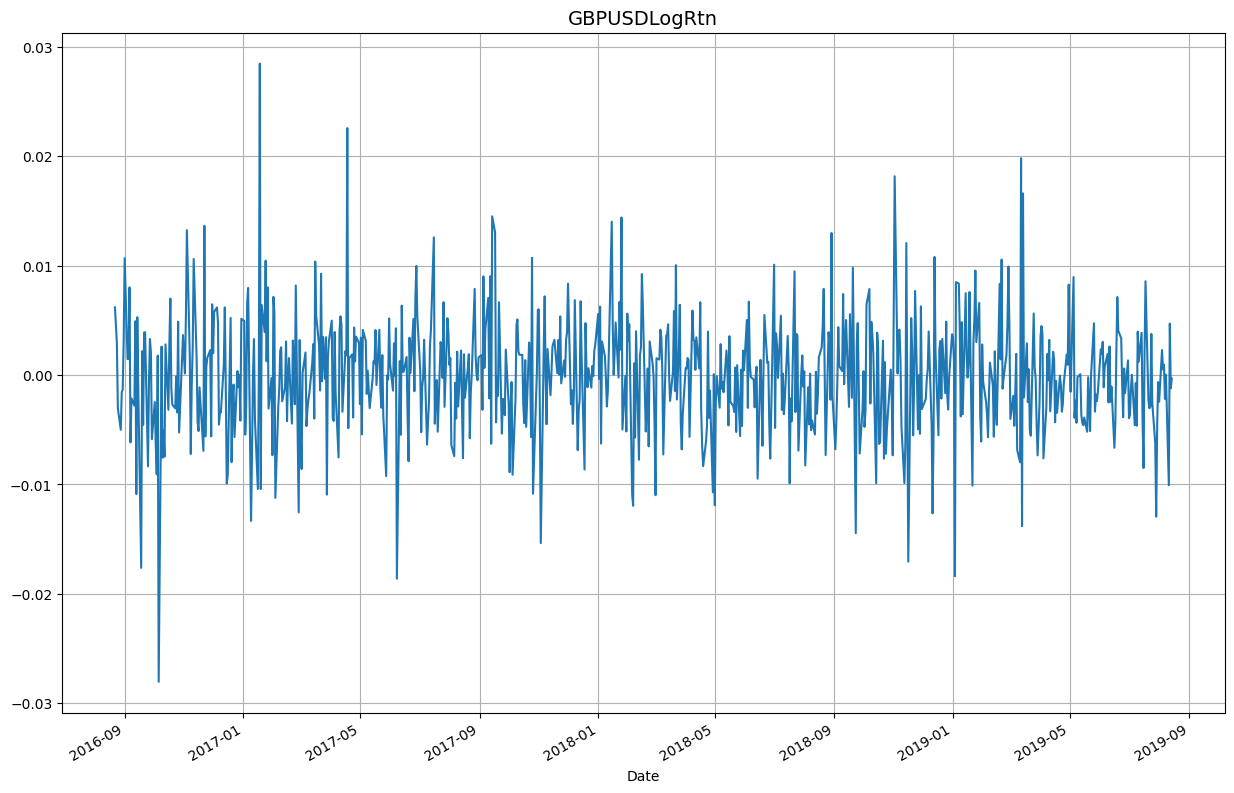

In [46]:
GBPUSDLogRtn.plot(figsize = (15, 10), grid = True)
plt.title('GBPUSDLogRtn', fontsize=14)
plt.show()

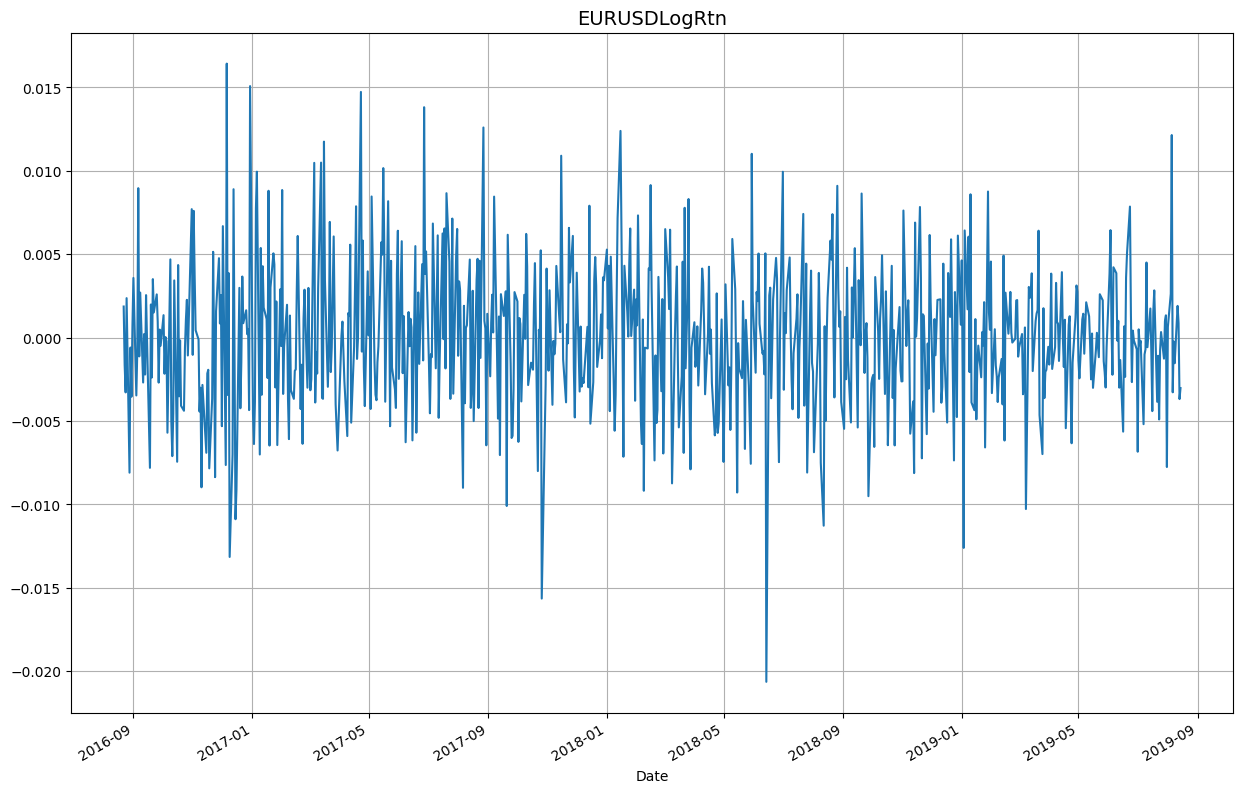

In [47]:
EURUSDLogRtn.plot(figsize = (15, 10), grid = True)
plt.title('EURUSDLogRtn', fontsize=14)
plt.show()

In [48]:
GBPUSDLogRtn.describe()


count    775.000000
mean      -0.000102
std        0.005366
min       -0.028047
25%       -0.003351
50%        0.000000
75%        0.003090
max        0.028480
Name: Close, dtype: float64

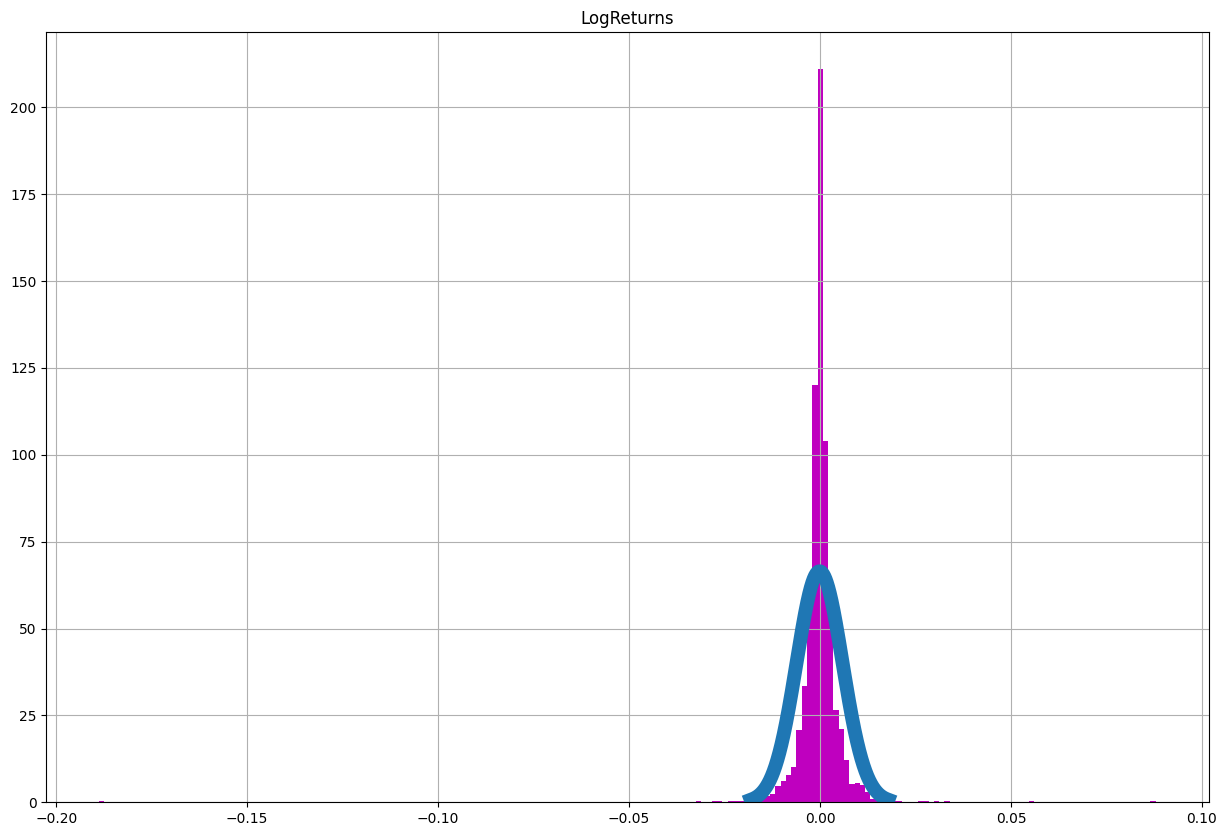

-10.869515002988066 412.3473222932795


In [49]:
EURCHFLogRtn.hist(bins = 200, figsize = (15 ,10), color='m', density = True)
plt.title('LogReturns')
mu =EURCHFLogRtn.mean()
sigma = EURCHFLogRtn.std()
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 2419)
plt.plot(x, stats.norm.pdf(x, mu, sigma), linewidth= 10)
plt.show()
print(EURCHFLogRtn.skew(),EURCHFLogRtn.kurt())

In [50]:
EURUSDLogRtn.describe()

count    775.000000
mean      -0.000018
std        0.004402
min       -0.020638
25%       -0.002909
50%       -0.000092
75%        0.002720
max        0.016431
Name: Close, dtype: float64

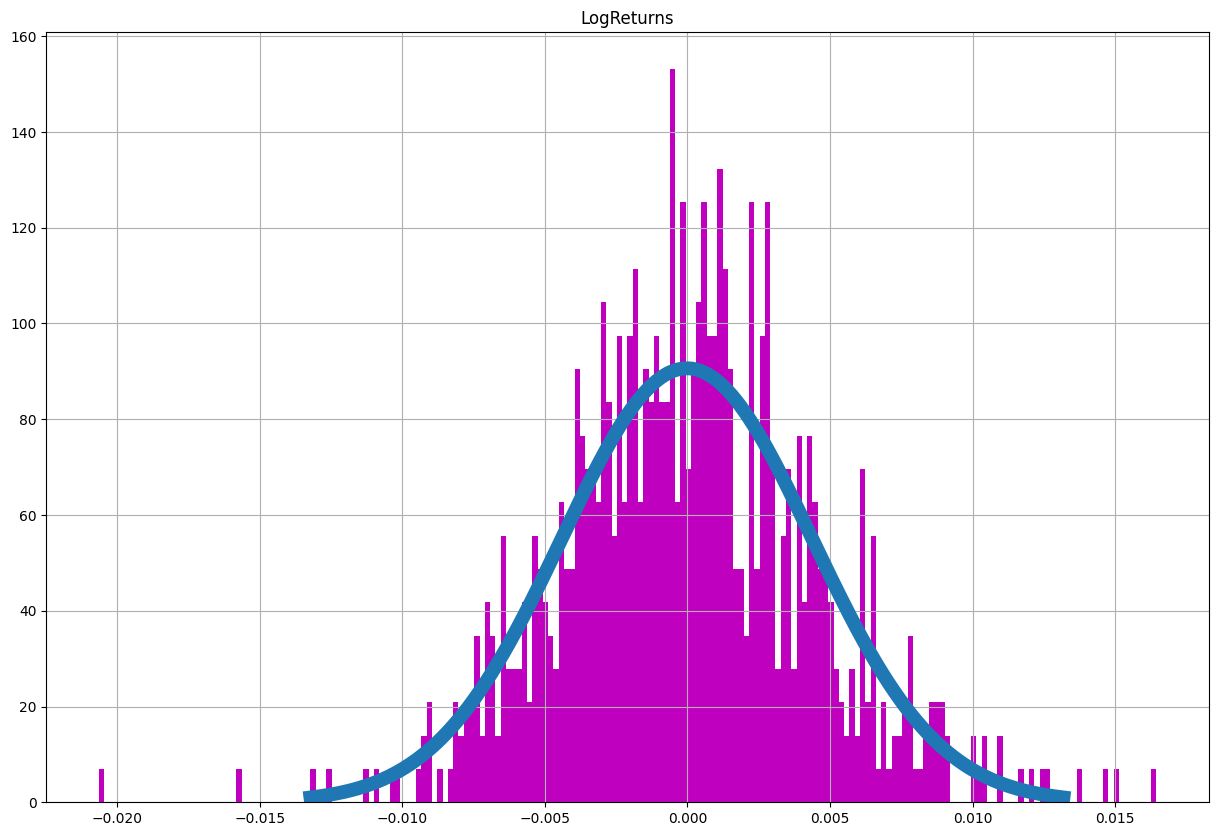

In [51]:
EURUSDLogRtn.hist(bins = 200, figsize = (15 ,10), color='m', density = True)
plt.title('LogReturns')
mu = EURUSDLogRtn.mean()
sigma = EURUSDLogRtn.std()
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 2419)
plt.plot(x, stats.norm.pdf(x, mu, sigma), linewidth= 10)
plt.show()

In [52]:
skew= EURUSDLogRtn.skew()
n=len(EURUSDLogRtn)
t_skew = skew/m.sqrt(6/n)
p_value_s = sp.stats.norm.sf(abs(t_skew))*2
print(t_skew, p_value_s)

1.0418325792480505 0.29748930662132145


In [53]:
kurt= EURUSDLogRtn.kurt()
n=len(EURUSDLogRtn)
t_kurt = (kurt-3)/m.sqrt(24/n)
p_value_k = sp.stats.norm.sf(abs(t_kurt))*2
print(t_kurt, p_value_k)

-11.135869001263387 8.392246346525626e-29


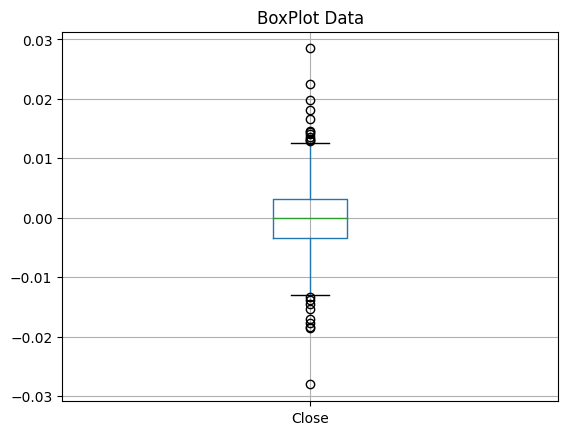

In [54]:
dataBXP = pd.DataFrame(GBPUSDLogRtn).boxplot()
plt.title('BoxPlot Data')
plt.show()

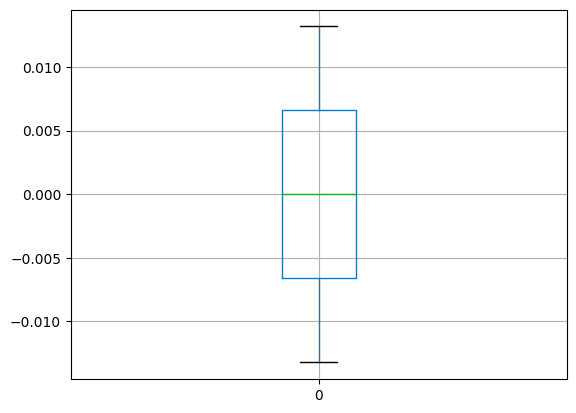

In [55]:
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 2419)
y = stats.norm.pdf(x, mu, sigma)
normDf = pd.DataFrame(x,y)
normBXP = normDf.boxplot()

Exercises
===

1. Repeat EDA for another 3 stocks (your choice!) and compare histograms as above
2. Similar exercise for 4 stocks from Banking (!?) 
3. Divide period for the time serise for Google in 3. Examine similar stats on the different periods. Are there any conclusions you can draw?

QQ Plot 
===


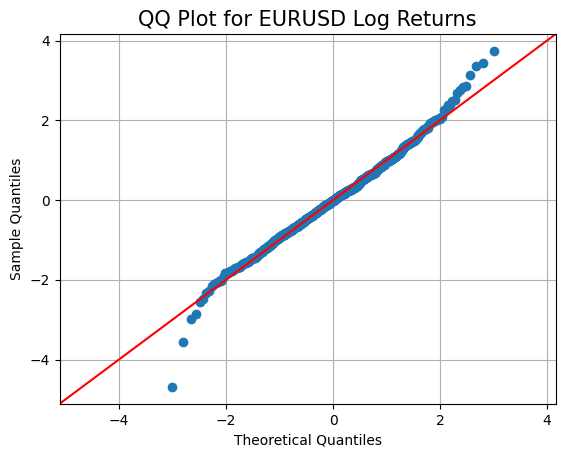

In [56]:
import statsmodels.api as sm
#from pandas.core import datetools
EURUSDDataLogRtn = np.log(EURUSD['Close']).diff().dropna()
fig = sm.qqplot(EURUSDDataLogRtn,fit=True, line='45')
plt.title('QQ Plot for EURUSD Log Returns', fontsize=15)
plt.grid()
plt.show()

In [57]:
EURUSDDataLogRtn = np.log(EURUSD['Close']).diff().dropna()
GBPUSDDataLogRtn = np.log(GBPUSD['Close']).diff().dropna()
USDJPYDataLogRtn = np.log(USDJPYFull['Close']).diff().dropna()
EURCHFDataLogRtn = np.log(EURCHF['Close']).diff().dropna()

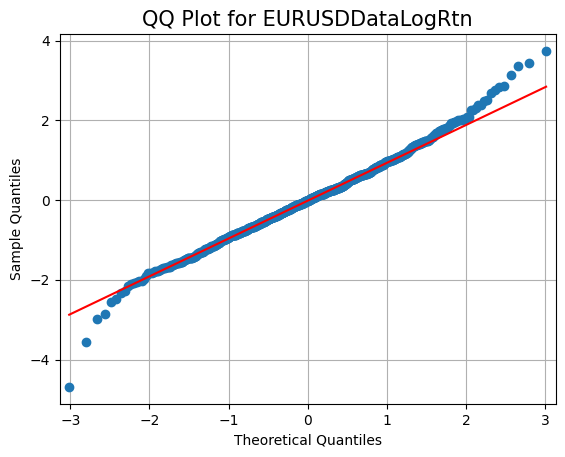

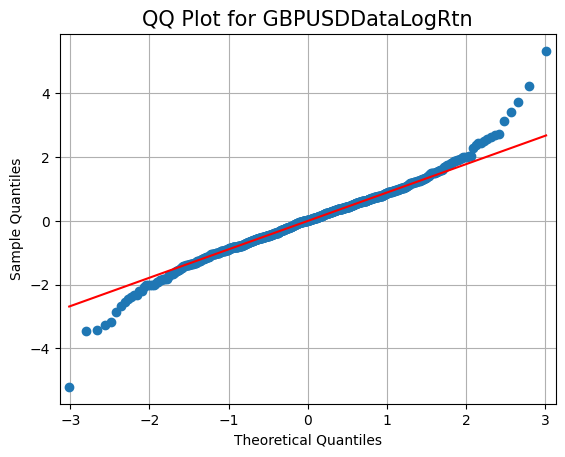

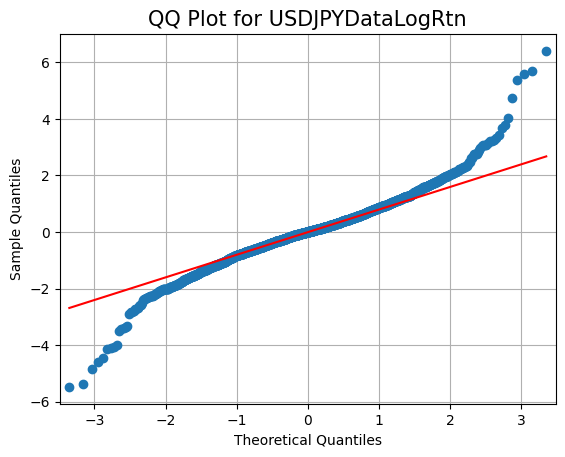

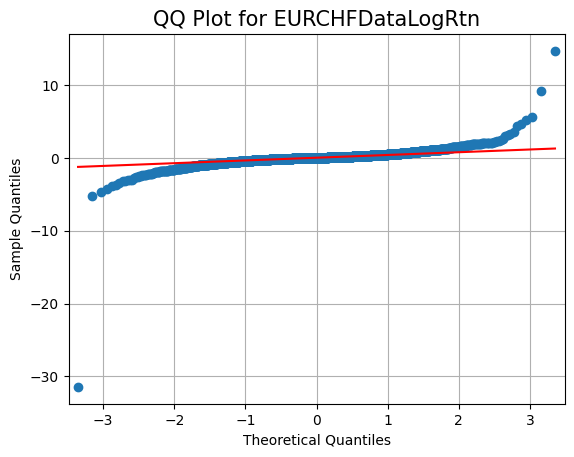

In [58]:
fig = sm.qqplot(EURUSDDataLogRtn,fit=True, line='q')
plt.title('QQ Plot for EURUSDDataLogRtn', fontsize=15)
plt.grid()
fig = sm.qqplot(GBPUSDDataLogRtn,fit=True, line='q')
plt.title('QQ Plot for GBPUSDDataLogRtn', fontsize=15)
plt.grid()
fig = sm.qqplot(USDJPYDataLogRtn,fit=True, line='q')
plt.title('QQ Plot for USDJPYDataLogRtn', fontsize=15)
plt.grid()
fig = sm.qqplot(EURCHFDataLogRtn,fit=True, line='q')
plt.title('QQ Plot for EURCHFDataLogRtn', fontsize=15)
plt.grid()
plt.show()

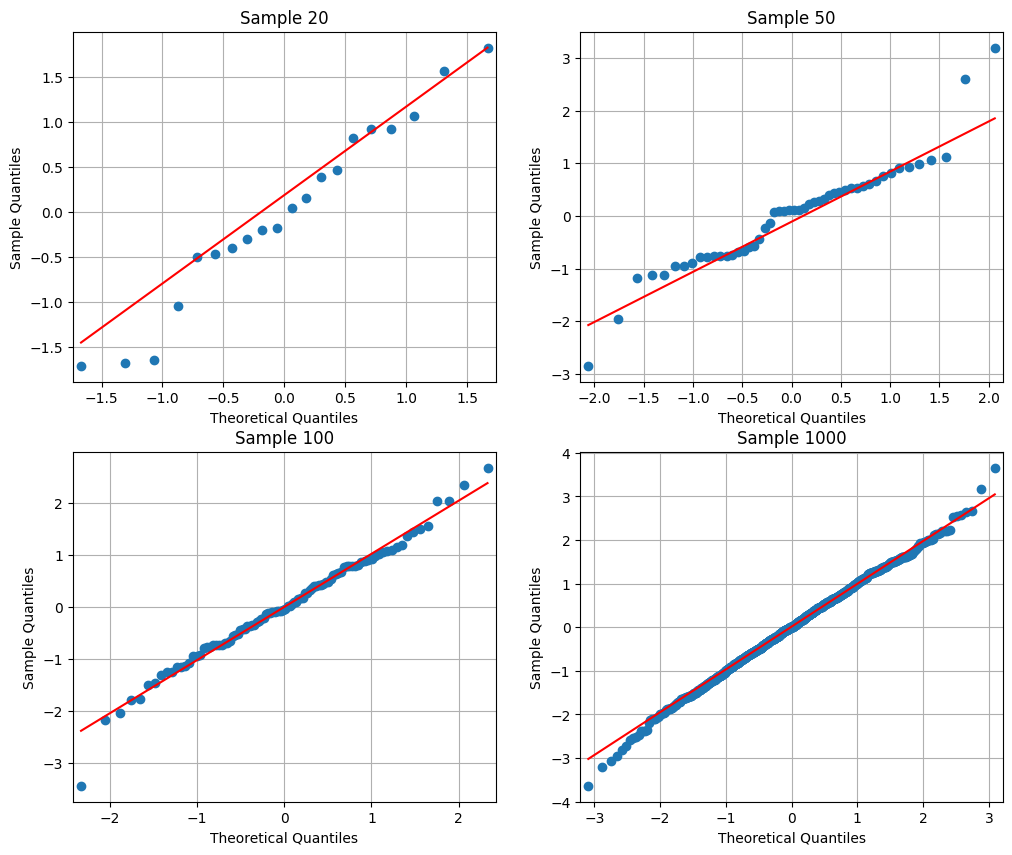

In [59]:
np.random.seed(17)
nd1 = stats.norm(0,1).rvs(size=20)
nd2 = stats.norm(0,1).rvs(size=50)
nd3 = stats.norm(0,1).rvs(size=100)
nd4 = stats.norm(0,1).rvs(size=1000)

arr1 = []
arr1.append(nd1)
arr1.append(nd2)
arr1.append(nd3)
arr1.append(nd4)
title1 = ["Sample 20","Sample 50","Sample 100", "Sample 1000"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,10))
ax= axes.flatten()
for i in range(4):
    sm.qqplot((arr1[i]), fit = True, line='q',ax = ax[i])
    ax[i].grid()
    ax[i].set_title(title1[i])
plt.show()


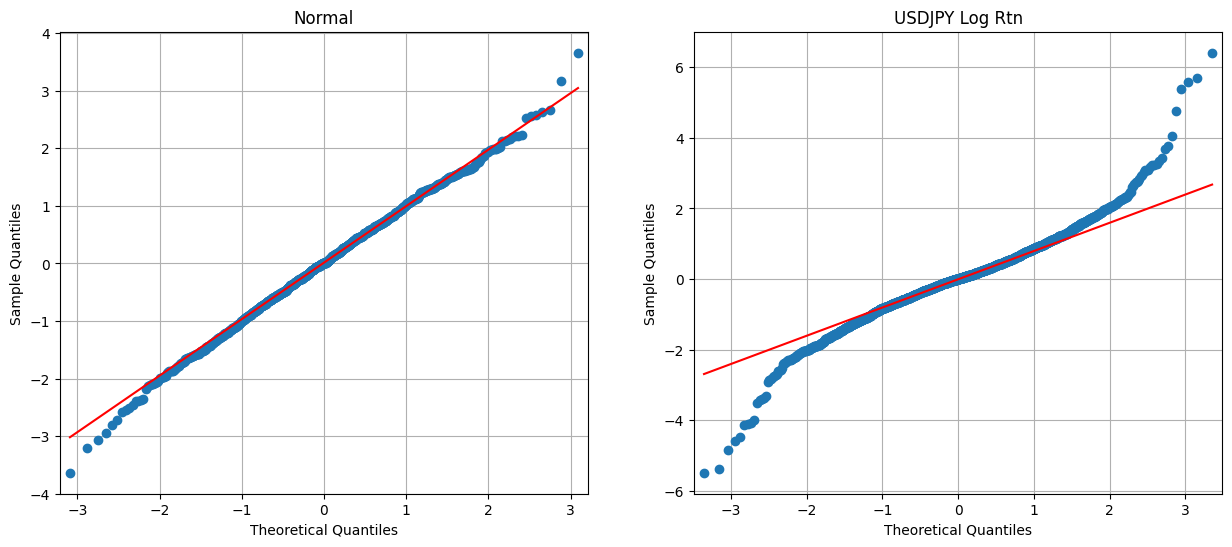

In [60]:
normDist = nd4

x = []
x.append(normDist)
x.append(USDJPYDataLogRtn)
title2 = ["Normal", "USDJPY Log Rtn"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,6))
ax= axes.flatten()
for i in range(2):
    sm.qqplot((x[i]), fit = True, line='q',ax = ax[i])
    ax[i].grid()
    ax[i].set_title(title2[i])
plt.show()

In [61]:
ax[0].hist(normDist,bins = 300, color='m', density = True)
x = np.linspace(- 3,3, 10000) # x values around mean of log normal returns and 
ax[0].plot(x,stats.norm.pdf(x, 0, 1), linewidth= 10)
ax[0].set_title('Histogram of Log Returns vs Normal Density')
ax[0].grid(True)



In [62]:
np.random.seed(17)
first_distribution = stats.norm(-100,20).rvs(size=1000)
second_distribution = stats.norm(2,1).rvs(size=1000)
combined_norm = np.concatenate((first_distribution, second_distribution))
print(combined_norm.mean())
print(len(combined_norm))

-48.752268105794485
2000


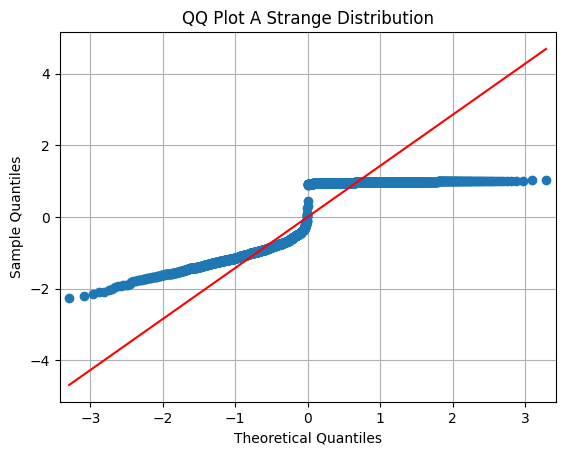

In [63]:
fig = sm.qqplot(combined_norm,fit=True, line='q')
plt.title('QQ Plot A Strange Distribution', fontsize=12)
plt.grid()
plt.show()

In [64]:
from statsmodels.distributions.mixture_rvs import mixture_rvs
np.random.seed(12345) # Seed the random number generator for reproducible results


In [65]:
dist1_loc, dist1_scale, weight1 = -1 , .5, .25
dist2_loc, dist2_scale, weight2 = 1 , .5, .75

# Sample from a mixture of distributions
obs_dist = mixture_rvs(prob=[weight1, weight2], size=250,
                        dist=[stats.norm, stats.norm],
                        kwargs = (dict(loc=dist1_loc, scale=dist1_scale),
                                  dict(loc=dist2_loc, scale=dist2_scale)))
kde = sm.nonparametric.KDEUnivariate(obs_dist)
kde.fit() # Estimate the densities

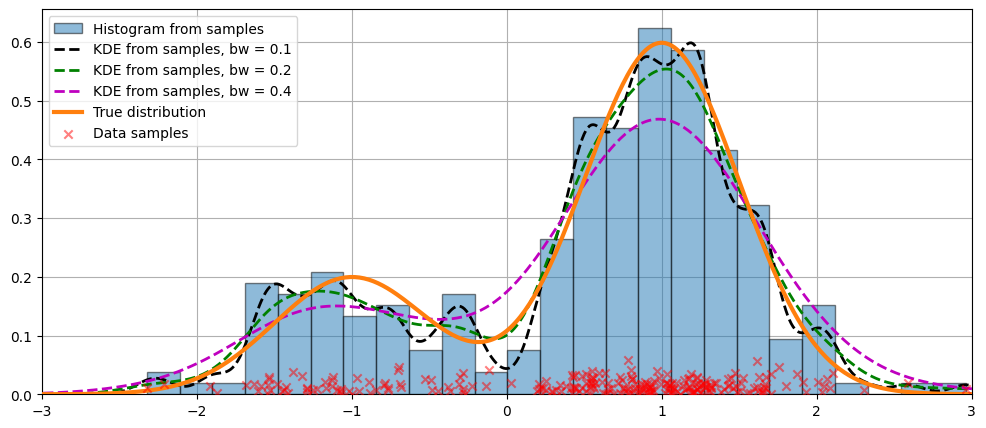

In [66]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(111)

# Plot the histrogram
ax.hist(obs_dist, bins=25, label='Histogram from samples',
        zorder=5, edgecolor='k', density=True, alpha=0.5)

# Plot the KDE for various bandwidths
for bandwidth in [0.1]:
    kde.fit(bw=bandwidth) # Estimate the densities
    ax.plot(kde.support, kde.density, '--', lw=2, color='k', zorder=10,
            label='KDE from samples, bw = {}'.format(round(bandwidth, 2)))
    
for bandwidth in [0.2]:
    kde.fit(bw=bandwidth) # Estimate the densities
    ax.plot(kde.support, kde.density, '--', lw=2, color='g', zorder=10,
            label='KDE from samples, bw = {}'.format(round(bandwidth, 2)))
    
for bandwidth in [0.4]:
    kde.fit(bw=bandwidth) # Estimate the densities
    ax.plot(kde.support, kde.density, '--', lw=2, color='m', zorder=10,
            label='KDE from samples, bw = {}'.format(round(bandwidth, 2)))

    
    true_values = (stats.norm.pdf(loc=dist1_loc, scale=dist1_scale, x=kde.support)*weight1
              + stats.norm.pdf(loc=dist2_loc, scale=dist2_scale, x=kde.support)*weight2)
    
# Plot the true distribution
ax.plot(kde.support, true_values, lw=3, label='True distribution', zorder=15)

# Plot the samples
ax.scatter(obs_dist, np.abs(np.random.randn(obs_dist.size))/50,
           marker='x', color='red', zorder=20, label='Data samples', alpha=0.5)

ax.legend(loc='best')
ax.set_xlim([-3, 3])
ax.grid(True, zorder=-5)


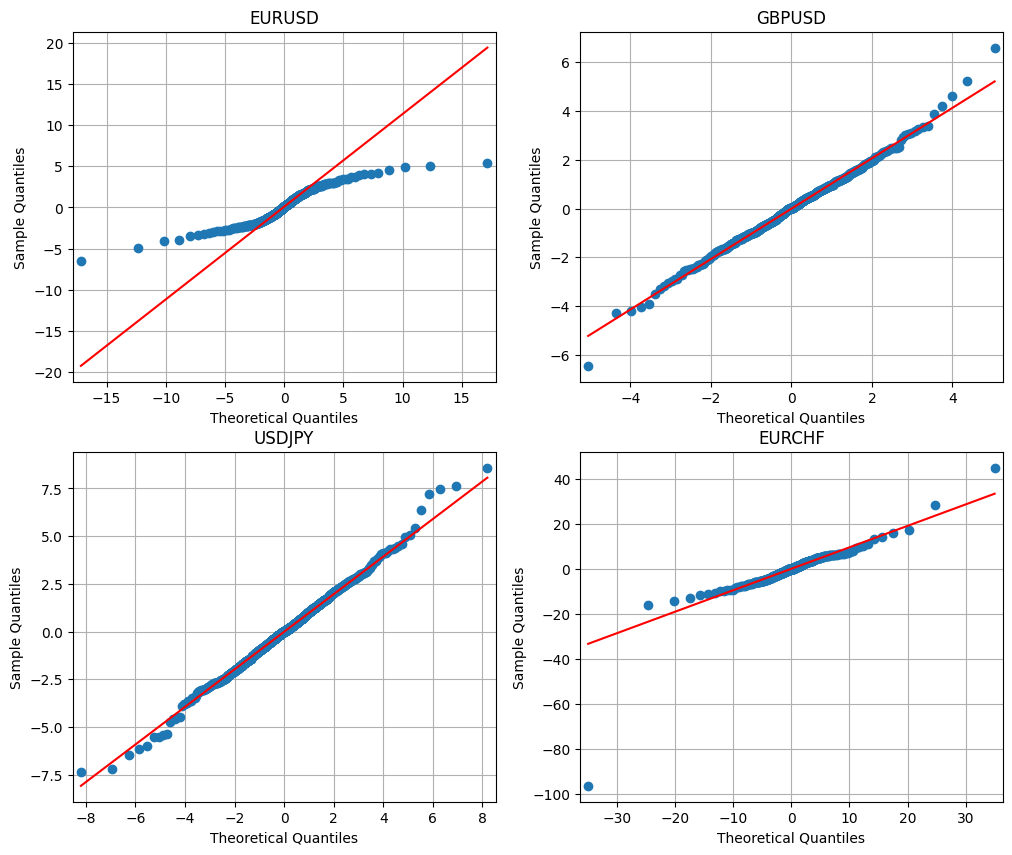

In [67]:
arr = []
arr.append(EURUSDDataLogRtn)
arr.append(GBPUSDDataLogRtn)
arr.append(USDJPYDataLogRtn)
arr.append(EURCHFDataLogRtn) 

title = ["EURUSD","GBPUSD","USDJPY","EURCHF"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,10))
ax= axes.flatten()
for i in range(4):
    sm.qqplot((arr[i]), stats.t, fit = True, line='q',ax = ax[i])
    ax[i].grid()
    ax[i].set_title(title[i])
plt.show()

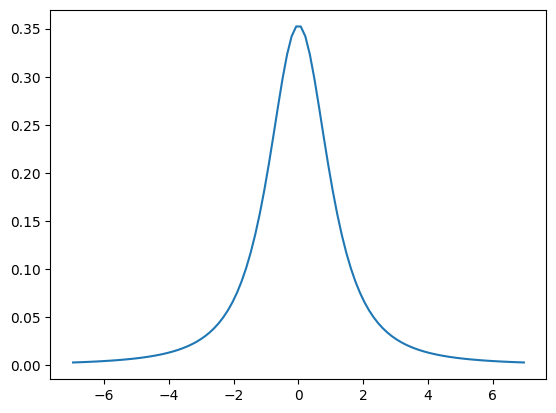

In [68]:
df = 2
x = np.linspace(stats.t.ppf(0.01,df), stats.t.ppf(0.99, df), 100)
y = stats.t.pdf(x, df, 0, 1)
plt.plot(x, y)

Text(0.5, 1.0, 'PDF of standardized t-Distr for various df')

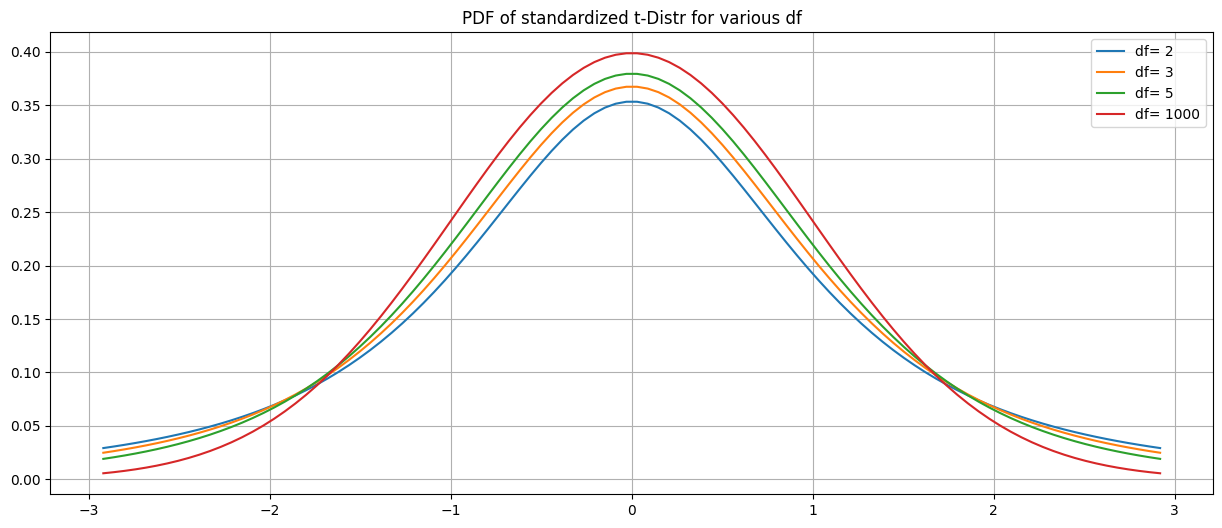

In [69]:
plt.figure(1, figsize=(15,6))

arr2 = []
arr2.append(2)
arr2.append(3)
arr2.append(5)
arr2.append(1000)

x = np.linspace(stats.t.ppf(0.05,df), stats.t.ppf(0.95, df), 100)

for i in range(4):   
    y = stats.t.pdf(x, arr2[i], 0, 1)
    plt.plot(x, y, label = 'df= {}'.format(arr2[i]))

plt.legend(loc='best')
plt.grid()
plt.title("PDF of standardized t-Distr for various df")



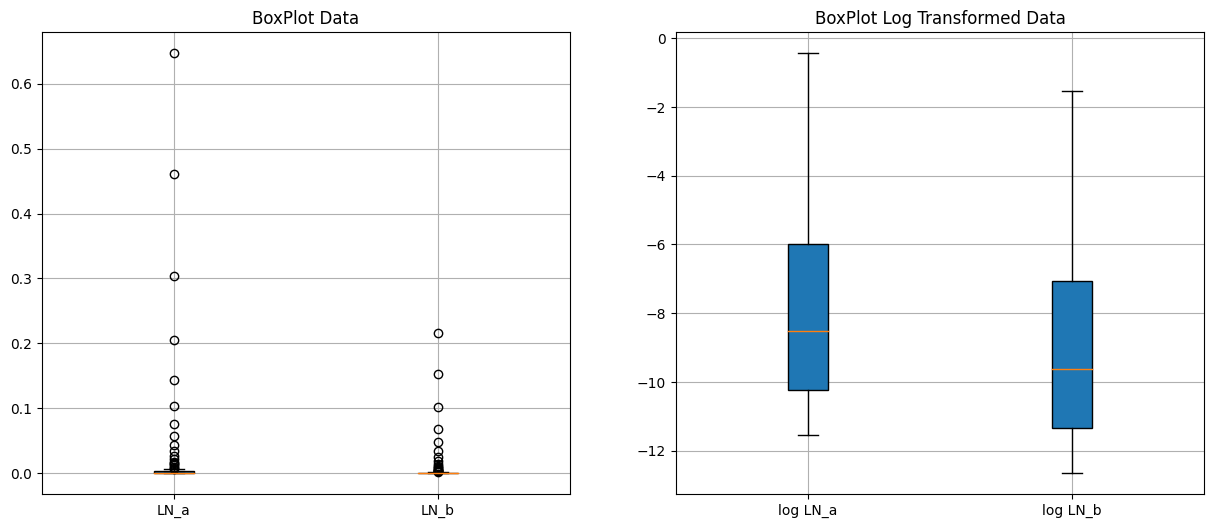

In [70]:
plt.figure(1, figsize=(15,6)) 

s1 = 1
scale1 = 4
loc1 = 1
x1 = np.linspace(stats.lognorm.ppf(0.0001,s1,scale1,loc1), stats.lognorm.ppf(0.9999, s1,scale1,loc1), 100)
y1 = stats.lognorm.pdf(x1, s1,scale1,loc1)

s2 = 1
scale2 = 4
loc2 = 3
x2 = np.linspace(stats.lognorm.ppf(0.0001,s2,scale2,loc2), stats.lognorm.ppf(0.9999, s2,scale2,loc2), 100)
y2 = stats.lognorm.pdf(x2, s2,scale2,loc2)


all_data = [y1,y2]
labels = ['LN_a', 'LN_b']

                
plt.subplot(1,2, 1)
plt.boxplot(all_data,vert=True, patch_artist=True, labels = labels);
plt.title('BoxPlot Data')
plt.grid()


all_data2 = [np.log(y1),np.log(y2)]
labels2 = ['log LN_a', 'log LN_b']

                
plt.subplot(1,2, 2)
plt.boxplot(all_data2,vert=True, patch_artist=True, labels = labels2);
plt.title('BoxPlot Log Transformed Data')
plt.grid()


In [71]:
y1.mean()

0.022584560594022352

In [72]:
y2.mean()

0.007528186864674117

In [73]:
y2.std()

0.029071039127576706

In [74]:
y1.std()

0.08721311738273015

In [75]:
stats.lognorm.pdf(1,4)

0.09973557010035816